In [1]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs
from desi_lowz_funcs import calc_normalized_dist
from desi_lowz_funcs import find_objects_nearby
# from construct_dwarf_galaxy_catalogs import process_sga_matches
from catalog_paper_plots import make_bar_pie


%load_ext autoreload
%autoreload 2


In [2]:
# cats = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/hidden_dwarf_candidates_qso_mws_scnd.fits")

# _, uni_idx = np.unique(cats["TARGETID"].data,return_index=True)

# cats_uni = cats[uni_idx]

# cats_uni = cats_uni[cats_uni["ORIGIN_SAMPLE"] != "MWS"]

# print(np.unique(cats_uni["ORIGIN_SAMPLE"]))

# print(len(cats_uni[cats_uni["ORIGIN_SAMPLE"] == "QSO"]))
# print(len(cats_uni[cats_uni["ORIGIN_SAMPLE"] == "SCND"]))

# ##apply emission line SNR cuts 3 on Halpha and Hbeta and OIII 5007 to be conservative on how we include objects in cat
# ## so match with fastspecfit



In [3]:
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# Option 1: load the MAIN extension directly as an Astropy Table
hdus =  fits.open(filename)

In [4]:
sample_colors = {"BGS_BRIGHT" : "#882255", "BGS_FAINT": "#CC6677", "LOWZ":"#DDCC77", "ELG": "#88CCEE" }


In [5]:
# Path to the catalog
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# Option 1: load the MAIN extension directly as an Astropy Table
tot_cat = Table.read(filename, hdu="MAIN")

tot_cat =  tot_cat[tot_cat["DWARF_MASKBIT"] == 0]


In [4]:
len(tot_cat)

350118

In [5]:
np.median(tot_cat["Z"])

0.08012845139675179

In [6]:
np.sum(tot_cat["Z"] > 0.2)/ len(tot_cat["Z"])

0.15104907488332506

In [8]:
print("< 6 Counts =", np.sum((tot_cat["LOG_MSTAR_M24"] < 6)))
print("6 < Mstar < 7 Counts =", np.sum((tot_cat["LOG_MSTAR_M24"] < 7) & (tot_cat["LOG_MSTAR_M24"] > 6)))
print("7 < Mstar < 8 Counts =", np.sum((tot_cat["LOG_MSTAR_M24"] < 8) & (tot_cat["LOG_MSTAR_M24"] > 7)))
print("8 < Mstar < 9 Counts =", np.sum((tot_cat["LOG_MSTAR_M24"] < 9) & (tot_cat["LOG_MSTAR_M24"] > 8)))
print("9 < Mstar < 9.25 Counts =", np.sum((tot_cat["LOG_MSTAR_M24"] < 9.25) & (tot_cat["LOG_MSTAR_M24"] > 9)))
 

< 6 Counts = 42
6 < Mstar < 7 Counts = 1433
7 < Mstar < 8 Counts = 38068
8 < Mstar < 9 Counts = 206562
9 < Mstar < 9.25 Counts = 104013


In [10]:
len(tot_cat)

350118

In [11]:
noelg_mask = tot_cat["SAMPLE"] != "ELG"

print("< 6 Counts =", np.sum((tot_cat[noelg_mask]["LOG_MSTAR_M24"] < 6)))
print("6 < Mstar < 7 Counts =", np.sum((tot_cat[noelg_mask]["LOG_MSTAR_M24"] < 7) & (tot_cat[noelg_mask]["LOG_MSTAR_M24"] > 6)))
print("7 < Mstar < 8 Counts =", np.sum((tot_cat[noelg_mask]["LOG_MSTAR_M24"] < 8) & (tot_cat[noelg_mask]["LOG_MSTAR_M24"] > 7)))
print("8 < Mstar < 9 Counts =", np.sum((tot_cat[noelg_mask]["LOG_MSTAR_M24"] < 9) & (tot_cat[noelg_mask]["LOG_MSTAR_M24"] > 8)))
print("9 < Mstar < 9.25 Counts =", np.sum((tot_cat[noelg_mask]["LOG_MSTAR_M24"] < 9.25) & (tot_cat[noelg_mask]["LOG_MSTAR_M24"] > 9)))



< 6 Counts = 11
6 < Mstar < 7 Counts = 332
7 < Mstar < 8 Counts = 7796
8 < Mstar < 9 Counts = 111330
9 < Mstar < 9.25 Counts = 87939


In [12]:
len(tot_cat[noelg_mask])

207408

/tmp/ipykernel_1372846/1482331853.py:87: RuntimeWarning: divide by zero encountered in log10
  mu_r = tot_cat["MAG_R"].data + 2.5*np.log10( 2*np.pi * (tot_cat["R50_R"].data**2) )


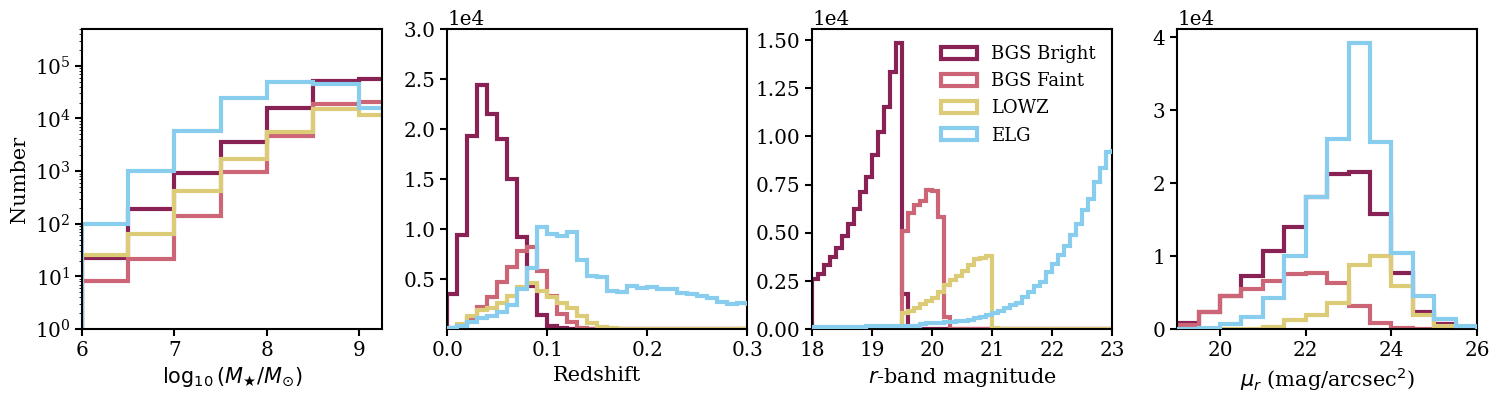

In [21]:


fig,ax = make_subplots(nrow=1,ncol=4,return_fig=True,col_spacing = 0.65,row_spacing = 0.5)

#first column will be stellar mass, and then redshift and stellar mass
    
text_titles = ["BGS Bright", "BGS Faint", "LOWZ", "ELG"]

samples = ["BGS_BRIGHT","BGS_FAINT","LOWZ","ELG"]

hist_lw = 3

mask_i = (tot_cat["SAMPLE"] == "BGS_BRIGHT")
ax[0].hist( tot_cat["LOG_MSTAR_M24"][mask_i], bins = np.arange(6,10,0.5), 
           color = sample_colors[samples[0]], histtype = "step", lw = hist_lw, zorder = 1,alpha = 1, label = "BGS Bright" )

mask_i = (tot_cat["SAMPLE"] == "BGS_FAINT" )
ax[0].hist( tot_cat["LOG_MSTAR_M24"][mask_i], bins = np.arange(6,10,0.5), 
           color = sample_colors[samples[1]], histtype = "step", lw = hist_lw, zorder = 1,label = "BGS Faint" )

mask_i = (tot_cat["SAMPLE"] == "LOWZ" )
ax[0].hist( tot_cat["LOG_MSTAR_M24"][mask_i], bins = np.arange(6,10,0.5), 
           color = sample_colors[samples[2]], histtype = "step", lw = hist_lw, zorder = 1,label = "LOWZ" )

mask_i = (tot_cat["SAMPLE"] == "ELG" )
ax[0].hist( tot_cat["LOG_MSTAR_M24"][mask_i], bins = np.arange(6,10,0.5), 
           color = sample_colors[samples[3]], histtype = "step", lw = hist_lw, zorder = 1,label = "ELG" )


ax[0].set_yscale("log")
ax[0].set_xlim([6,9.25])
ax[0].set_ylim([1,5e5])

binw = 0.01

text_titles = ["BGS Bright", "BGS Faint", "LOWZ", "ELG"]

mask_i = (tot_cat["SAMPLE"] == "BGS_BRIGHT")
ax[1].hist(tot_cat["Z"][mask_i], bins = np.arange(0,0.45,binw),
           color = sample_colors[samples[0]], histtype = "step", lw = hist_lw, zorder = 0,alpha = 1,density=False, label = "BGS Bright" )

mask_i = (tot_cat["SAMPLE"] == "BGS_FAINT" )
ax[1].hist( tot_cat["Z"][mask_i], bins = np.arange(0,0.45,binw),
           color = sample_colors[samples[1]], histtype = "step", lw = hist_lw, zorder = 1,label = "BGS Faint",density=False )

mask_i = (tot_cat["SAMPLE"] == "LOWZ" )
ax[1].hist( tot_cat["Z"][mask_i], bins = np.arange(0,0.45,binw),
           color = sample_colors[samples[2]], histtype = "step", lw = hist_lw, zorder = 2,density=False,label = "LOWZ")

mask_i = (tot_cat["SAMPLE"] == "ELG" )
ax[1].hist( tot_cat["Z"][mask_i], bins = np.arange(0,0.45,binw),
           color = sample_colors[samples[3]], histtype = "step", lw = hist_lw, zorder = 3,label = "ELG",density=False)


ax[1].set_xlim([0,0.3])
ax[1].set_ylim([1,3e4])
ax[1].ticklabel_format(style='sci', axis='y', scilimits=(0,0))

#

binw = 0.1

mask_i = (tot_cat["SAMPLE"] == "BGS_BRIGHT")
ax[2].hist(tot_cat["MAG_R"][mask_i], bins = np.arange(18,23.5,binw),
           color = sample_colors[samples[0]], histtype = "step", lw = hist_lw, zorder = 0,alpha = 1,density=False, label = "BGS Bright" )

mask_i = (tot_cat["SAMPLE"] == "BGS_FAINT" )
ax[2].hist( tot_cat["MAG_R"][mask_i], bins = np.arange(18,23.5,binw),
           color = sample_colors[samples[1]], histtype = "step", lw = hist_lw, zorder = 1,label = "BGS Faint",density=False )

mask_i = (tot_cat["SAMPLE"] == "LOWZ" )
ax[2].hist( tot_cat["MAG_R"][mask_i], bins = np.arange(18,23.5,binw),
           color = sample_colors[samples[2]], histtype = "step", lw = hist_lw, zorder = 2,density=False,label = "LOWZ")

mask_i = (tot_cat["SAMPLE"] == "ELG" )
ax[2].hist( tot_cat["MAG_R"][mask_i], bins = np.arange(18,23.5,binw),
           color = sample_colors[samples[3]], histtype = "step", lw = hist_lw, zorder = 3,label = "ELG",density=False)


ax[2].set_xlim([18,23])
ax[2].legend(frameon=False,fontsize = 13,loc = "upper right",ncol = 1)
ax[2].ticklabel_format(style='sci', axis='y', scilimits=(0,0))


#####

mur_bins = np.arange(19,26.5,0.5)

mu_r = tot_cat["MAG_R"].data + 2.5*np.log10( 2*np.pi * (tot_cat["R50_R"].data**2) )

mask_i = (tot_cat["SAMPLE"] == "BGS_BRIGHT")
ax[3].hist(mu_r[mask_i], bins = mur_bins,
           color = sample_colors[samples[0]], histtype = "step", lw = hist_lw, zorder = 0,alpha = 1,density=False, label = "BGS Bright" )

mask_i = (tot_cat["SAMPLE"] == "BGS_FAINT" )
ax[3].hist(mu_r[mask_i], bins = mur_bins,
           color = sample_colors[samples[1]], histtype = "step", lw = hist_lw, zorder = 1,label = "BGS Faint",density=False )

mask_i = (tot_cat["SAMPLE"] == "LOWZ" )
ax[3].hist( mu_r[mask_i], bins = mur_bins,
           color = sample_colors[samples[2]], histtype = "step", lw = hist_lw, zorder = 2,density=False,label = "LOWZ")

mask_i = (tot_cat["SAMPLE"] == "ELG" )
ax[3].hist( mu_r[mask_i], bins = mur_bins,
           color = sample_colors[samples[3]], histtype = "step", lw = hist_lw, zorder = 3,label = "ELG",density=False)

ax[3].set_xlim([np.min(mur_bins),np.max(mur_bins)])
ax[3].ticklabel_format(style='sci', axis='y', scilimits=(0,0))


##################

# make_bar_pie(ax[0], tot_cat, "LOGM_SAGA", bins =  np.arange(6-0.125/2, 9.5,0.125))

# ax[0].set_xlim(6, 9.25)
# ax[0].set_ylim(0, 1)
# # ax.set_title("Fractional Sample Composition vs Stellar Mass")

# make_bar_pie(ax[1], tot_cat, "Z", bins =  np.arange(0-0.025/2, 0.4,0.025) )
# ax[1].set_xlim(0.0, 0.3)
# ax[1].set_ylim(0, 1)


# make_bar_pie(ax[2], tot_cat, "MAG_R", bins =  np.arange(17,23.5,0.1) )
# ax[2].set_xlim(18, 23)
# ax[2].set_ylim(0, 1)

ax[3].set_xlabel(r"$\mu_r$ (mag/arcsec$^2$)",fontsize=15)
ax[2].set_xlabel(r"$r$-band magnitude",fontsize=15)
ax[1].set_xlabel("Redshift",fontsize=15)
ax[0].set_xlabel(r"$\log_{10}(M_{\bigstar}/M_{\odot})$",fontsize=15)

ax[0].set_ylabel(r"Number",fontsize = 15)

fig.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/dwarf_summaries.pdf",bbox_inches="tight")
plt.show()


In [190]:


dec_low = 0 - 5
dec_high = 0 + 5

slice_mask = (tot_cat["RA"] < 230) & (tot_cat["RA"] > 130) & (tot_cat["DEC"] > dec_low) & (tot_cat["DEC"] < dec_high) 

gama_g12_mask = (tot_cat["RA"] < 186) & (tot_cat["RA"] > 174) & (tot_cat["DEC"] > -3) & (tot_cat["DEC"] < 2) & (tot_cat["Z"] < 0.2) & (tot_cat["MAG_R"] < 19.8)
gama_g09_mask = (tot_cat["RA"] < 141) & (tot_cat["RA"] > 129) & (tot_cat["DEC"] > -2) & (tot_cat["DEC"] < 3) & (tot_cat["Z"] < 0.2) & (tot_cat["MAG_R"] < 19.8)

gama_g15_mask = (tot_cat["RA"] < 223.5) & (tot_cat["RA"] > 211.5) & (tot_cat["DEC"] > -2) & (tot_cat["DEC"] < 3) & (tot_cat["Z"] < 0.2)   & (tot_cat["MAG_R"] < 19.8)

tot_cat_slice = tot_cat[slice_mask]


tot_cat_slice["comov_dist"] = Planck18.comoving_distance(tot_cat_slice["Z"]).data



In [191]:
Planck18.comoving_distance(0.14)

<Quantity 599.58802138 Mpc>

In [193]:
# Suppose your Astropy table is called `tab`
samples_cat = tot_cat_slice["SAMPLE"].astype(str)  # Convert from bytes to string if necessary

sample_color_map = {"BGS_BRIGHT" : "#882255", "BGS_FAINT": "#CC6677", "LOWZ":"#DDCC77", "ELG": "#88CCEE" }
sample_color_map.items()

dict_items([('BGS_BRIGHT', '#882255'), ('BGS_FAINT', '#CC6677'), ('LOWZ', '#DDCC77'), ('ELG', '#88CCEE')])

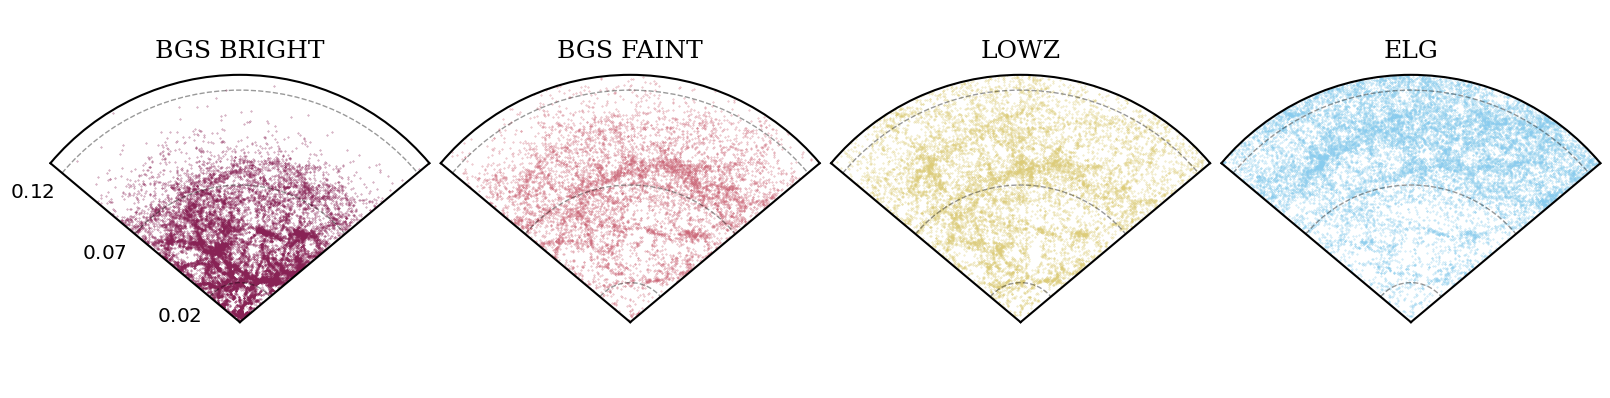

In [221]:

title_size = 19
ra_ticks_vals = np.array([130,150, 170, 190, 210, 230])
ra_min = 130
ra_max = 230
pad_val =-15

fig, ax = plt.subplots(1,4,figsize = (20,5),subplot_kw={'projection': 'polar'})
plt.subplots_adjust(wspace = 0.03, hspace = -1)

plot_ind = 0

ax = [ax[0], ax[1], ax[2], ax[3]  ]

for sample_name, color in sample_color_map.items():

    mask = samples_cat == sample_name
    
    ra_radians = np.deg2rad(tot_cat_slice[mask]["RA"])

    
    ax[plot_ind].grid(True, axis='y', linewidth=1, alpha=0.4,color="k",ls="--")
    ax[plot_ind].grid(False, axis='x')
            
    
    ax[plot_ind].scatter(ra_radians, tot_cat_slice["comov_dist"][mask], alpha=0.7,s=0.1,rasterized=True, color = color )
    
    # Add labels and a colorbar
    ax[plot_ind].set_theta_zero_location("S")  # Optional: sets 0° at the bottom (South)
    ax[plot_ind].set_theta_direction(-1)       # Optional: clockwise direction for RA
    # Set title and labels
    # ax.set_title('Galaxy Distribution by Redshift and RA')
    ax[plot_ind].set_thetamin(ra_min)   # Min angle in degrees (start of the slice)
    ax[plot_ind].set_thetamax(ra_max)
    ax[plot_ind].set_rlim(0,550)

    ax[plot_ind].set_rticks([88,305,516])

    ax[plot_ind].set_xticks([])
    # labels only on first panel
    if plot_ind == 0:
        ax[plot_ind].set_yticklabels([r"$0.02$", r"$0.07$", r"$0.12$"])
    else:
        pass
        ax[plot_ind].tick_params(axis='y', labelleft=False)


    if "BGS_" in sample_name:
        sample_name = sample_name.replace("BGS_", "BGS ")

    ax[plot_ind].text(np.deg2rad(180),        # angle in radians
        ax[plot_ind].get_rmax() * 1.1,   # just outside the outermost circle
        sample_name,
        color = "k",
        rotation=0,
        ha='center',
        va='center',
        fontsize=18)
    
    plot_ind += 1

# plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/zred_sample_slice.png",bbox_inches="tight")

plt.show()
    

In [196]:
Planck18.comoving_distance(0.02), Planck18.comoving_distance(0.07), Planck18.comoving_distance(0.12) 

(<Quantity 88.20208831 Mpc>,
 <Quantity 305.02911976 Mpc>,
 <Quantity 516.51109372 Mpc>)

In [165]:
from desi_lowz_funcs import get_stellar_mass_mia
from catalog_paper_plots import make_cmap

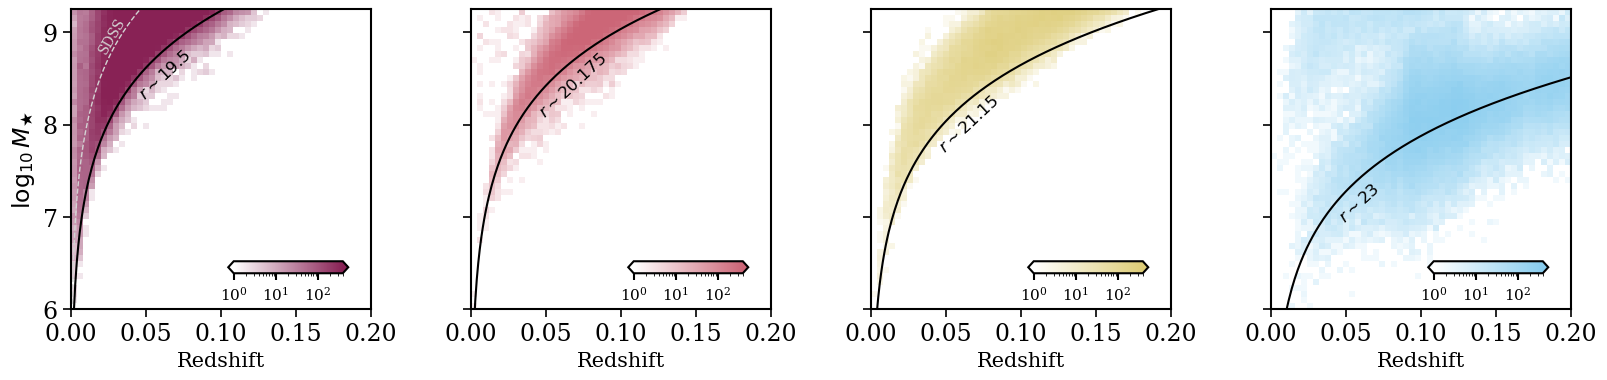

In [228]:

### 2d redshift vs. stellar mass distribution 

zgrid = np.arange(0.001,0.31,0.001)
gr_col = 0.2
mstar_195= get_stellar_mass_mia(gr_col,19.5,zgrid)
mstar_20= get_stellar_mass_mia(gr_col,20,zgrid)
mstar_21= get_stellar_mass_mia(gr_col,21,zgrid)
mstar_23= get_stellar_mass_mia(gr_col,23,zgrid)

mstar_grids = [ mstar_195, mstar_20, mstar_21, mstar_23 ]
labels = [r"$r \sim 19.5$", r"$r \sim 20.175$", r"$r \sim 21.15$", r"$r \sim 23$" ]
rmag_lims = [19.5, 20.175, 21.15, 23]


def fmt(x):
    return rf"r = %d"%x


fig,ax = make_subplots(ncol=4,nrow=1,return_fig=True,col_spacing = 1, row_spacing = 0.8)

samples = ["BGS_BRIGHT","BGS_FAINT","LOWZ","ELG"]

for i in range(1,4):
    ax[i].set_yticklabels([])

zmax = 0.2

for i in range(4):
    mask_i = (tot_cat["SAMPLE"] == samples[i] )
    
    cmap_i = make_cmap(sample_colors[samples[i]] )
    
    hist = ax[i].hist2d( tot_cat["Z"][mask_i], tot_cat["LOG_MSTAR_M24"][mask_i], range= ( (0,zmax), (6,9.25) ) , bins = 50, norm=LogNorm(vmin=1,vmax=400),cmap = cmap_i)
    ax[i].set_xlabel("Redshift",fontsize = 15)

    ##assuming an average color, of lets say g-r = 0.3, can I obtain a line for r ~ 19.5, 21, and 23
    ax[i].plot(zgrid, mstar_grids[i], color = "k",lw = 1.5)
    zind = 35
    ax[i].text(zgrid[zind]+0.0075,mstar_grids[i][zind] - 0.05,labels[i],color = "k",fontsize = 12,rotation =43)

    if i == 0:
        mstar_17= get_stellar_mass_mia(gr_col,17.7,zgrid)
        ax[i].text(0.017,8.78,"SDSS",color = "lightgrey",fontsize = 10,rotation =60)
        ax[i].plot(zgrid, mstar_17, color = "lightgrey",lw = 1,ls = "--")
        

    # ax[i].set_title(f"{text_titles[i]}", fontsize = 18)

    ax[i].set_xticks([0,0.05,0.1,0.15,0.2])
    # ax[i].set_xticklabels(["0.0", "","0.1","","0.2"])

    ax[i].tick_params(
            axis='both',
            which='major',
            labelsize=17,   # <-- change this
            length=6,
            width=1.2
        )
        
    ax[0].set_ylabel(r"$\log_{10}M_{\bigstar}$",fontsize = 17)

    fig.canvas.draw()

    # Get subplot position in figure coordinates
    p = ax[i].get_position().get_points().flatten()

    # Set colorbar size and position below the subplot
    cbar_height = 0.02
    cbar_padding = 0.06

    cax = fig.add_axes([
        p[0]+0.525*(p[2]-p[0]),                  # x0
        p[1] + cbar_padding,   # y0: a bit below the axis
        0.4*(p[2] - p[0]),           # width
        cbar_height            # height
    ])

    cbarticks = [1,1e1, 1e2, 500]
    cbar = plt.colorbar(hist[3], cax=cax, orientation='horizontal',
                        ticklocation='bottom', extend='both', ticks=cbarticks)
    cbar.ax.tick_params(labelsize=11)

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/zred_mstar_2d.png",bbox_inches="tight")
plt.show()

0.23676265245361172 0.07995455198868778
0.20973712987485982 0.08322960633042482
0.4345890832361228 0.14445953741981302
0.1519904989862244 0.019239622199030897


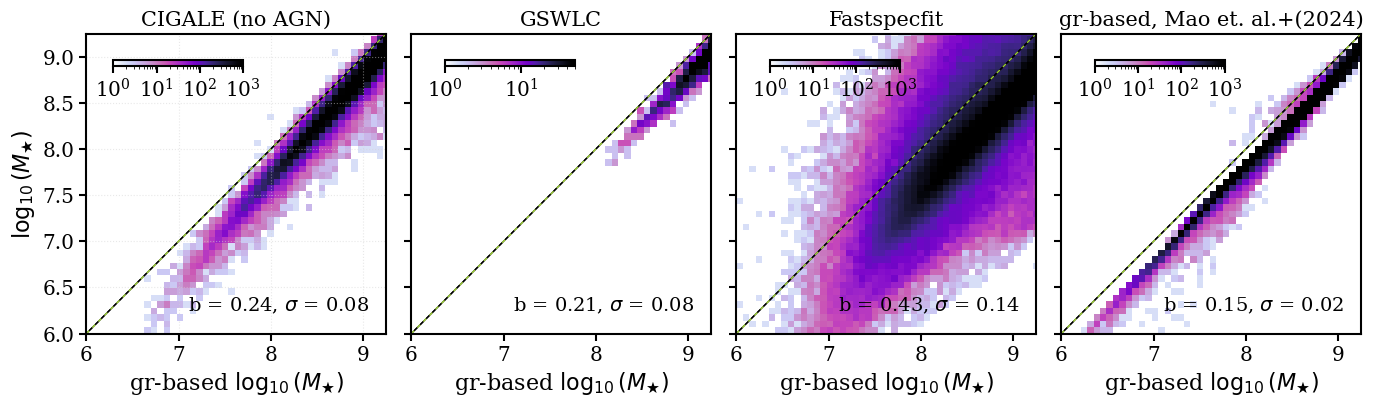

## Make the catalog image grid plot!

In [70]:
from desi_lowz_funcs import save_jpg
import matplotlib.image as mpimg
import requests

In [71]:
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# load the MAIN extension directly as an Astropy Table
data_cat_all = Table.read(filename, hdu="MAIN")

data_cat_all = data_cat_all[data_cat_all["DWARF_MASKBIT"] == 0]

In [72]:
# Example bins
rmag_bins = np.arange(17,21,0.25)
rmag_bins =  np.concatenate([[0], rmag_bins, [23] ] )
print(len(rmag_bins))
print(rmag_bins)

logm_bins = np.arange(6,9.5,0.5) 

mstar_vals = data_cat_all["LOG_MSTAR_M24"].data
rmag_vals = data_cat_all["MAG_R"].data

image_size = 115
save_path = "/pscratch/sd/v/virajvm/trash/desi_imgs"

session = requests.Session()

def swap(new_tgid):
    ra_i = data_cat_all[data_cat_all["TARGETID"] == new_tgid]["RA"][0]
    dec_i = data_cat_all[data_cat_all["TARGETID"] == new_tgid]["DEC"][0]
    return ra_i, dec_i, new_tgid
    
# Dummy images
images = {}
counts = {}
for i in range(len(rmag_bins)-1):
    for j in range(len(logm_bins)-1):
        logm_mask = (mstar_vals > logm_bins[j]) & (mstar_vals < logm_bins[j+1])
        rmag_mask = (rmag_vals > rmag_bins[i]) & (rmag_vals < rmag_bins[i+1])

        cat_i = data_cat_all[rmag_mask & logm_mask]

        if len(cat_i) == 0:
            img = None #np.ones((image_size,image_size))
        else:    
            ra_i = cat_i["RA"].data[0]
            dec_i = cat_i["DEC"].data[0]
            tgid_i = cat_i["TARGETID"].data[0]

            if tgid_i == 39627600477290925:
                ra_i, dec_i, tgid_i = swap(39628516483926392)
            if tgid_i == 39627403265312105:
                ra_i, dec_i, tgid_i = swap(39627715183120706)    
            if tgid_i == 39627824155330825:
                ra_i, dec_i, tgid_i = swap(39628268134994442)    
            if tgid_i == 39627672900340781:
                ra_i, dec_i, tgid_i = swap(39627769608406676)    
            
            img_path = save_path + f"/img_{tgid_i}.jpg"
            #check if img exists first
            if os.path.exists(img_path):
                img = mpimg.imread(img_path)
            else:
                save_jpg(ra_i,dec_i,img_path,session, size=image_size)
                
                img = mpimg.imread(img_path)
        
        images[(i,j)] = img
        counts[(i,j)] = len(cat_i)

18
[ 0.   17.   17.25 17.5  17.75 18.   18.25 18.5  18.75 19.   19.25 19.5
 19.75 20.   20.25 20.5  20.75 23.  ]


In [73]:
def plot_tight_image_grid(images, counts, rmag_bins, logm_bins,fontsize = 30):
    Nx = len(rmag_bins) - 1  # 15
    Ny = len(logm_bins) - 1  # 6

    fig, axes = plt.subplots(Ny, Nx, figsize=(int(Nx*2), int(Ny*2)))
    plt.subplots_adjust(wspace=0.015, hspace=0.015)  # remove space between subplots

    for j in range(Ny):
        for i in range(Nx):
            ax = axes[Ny - 1 - j, i]  # invert y so low mass is bottom
            img = images.get((i, j))

            if img is not None:
                ax.imshow(
                    img,
                    aspect='equal',
                    rasterized=True
                )

            ax.set_xticks([])
            ax.set_yticks([])
            ctsi = counts[(i,j)]
            if ctsi == 0:
                color_i ="k"
            else:
                color_i ="white"
                
            ax.text(0.925,0.85,ctsi, color=color_i, fontsize=fontsize-15,transform=ax.transAxes,ha="right",va="center")

            for spine in ax.spines.values():
                spine.set_visible(False)
            
            # Add axis labels only at edges
            if j == 0: # and i != Nx-1:  # bottom row: show rmag
                if rmag_bins[i+1] == 23:
                    ax.set_xlabel(f"{int(rmag_bins[i+1])}", fontsize=fontsize-12.5, rotation=0, labelpad=5,color = "k")
                    ax.xaxis.set_label_coords(1, -0.05)
                    
                elif rmag_bins[i+1] == 17:
                    ax.set_xlabel(fr"$<${int(rmag_bins[i+1])}", fontsize=fontsize-12.5, rotation=0, labelpad=5,color = "k")
                    ax.xaxis.set_label_coords(1, -0.05)
                elif rmag_bins[i+1] == 20.75:
                    ax.set_xlabel(fr"{rmag_bins[i+1]:.2f}$<$", fontsize=fontsize-12.5, rotation=0, labelpad=5,color = "k")
                    ax.xaxis.set_label_coords(1, -0.05)
                else:
                    ax.set_xlabel(f"{rmag_bins[i+1]:.2f}", fontsize=fontsize-12.5, rotation=0, labelpad=5,color = "k")
                    ax.xaxis.set_label_coords(1, -0.05)
            
            if i == 0:  # left column: show logM*
                ax.set_ylabel(f"{logm_bins[j]:.2f}", fontsize=fontsize-12.5, rotation=0, color="k")
                ax.yaxis.set_label_coords(-0.2, 0)

    # Add a big text label for the quantities being binned
    fig.text(0.5, 0.05, r"$r_{\rm mag}$", ha='center', va='center', fontsize=fontsize-5+2)
    fig.text(0.1, 0.5, r"$\log_{10} M_{\bigstar}$", ha='center', va='center', rotation='vertical', fontsize=fontsize-5)

    return fig, axes


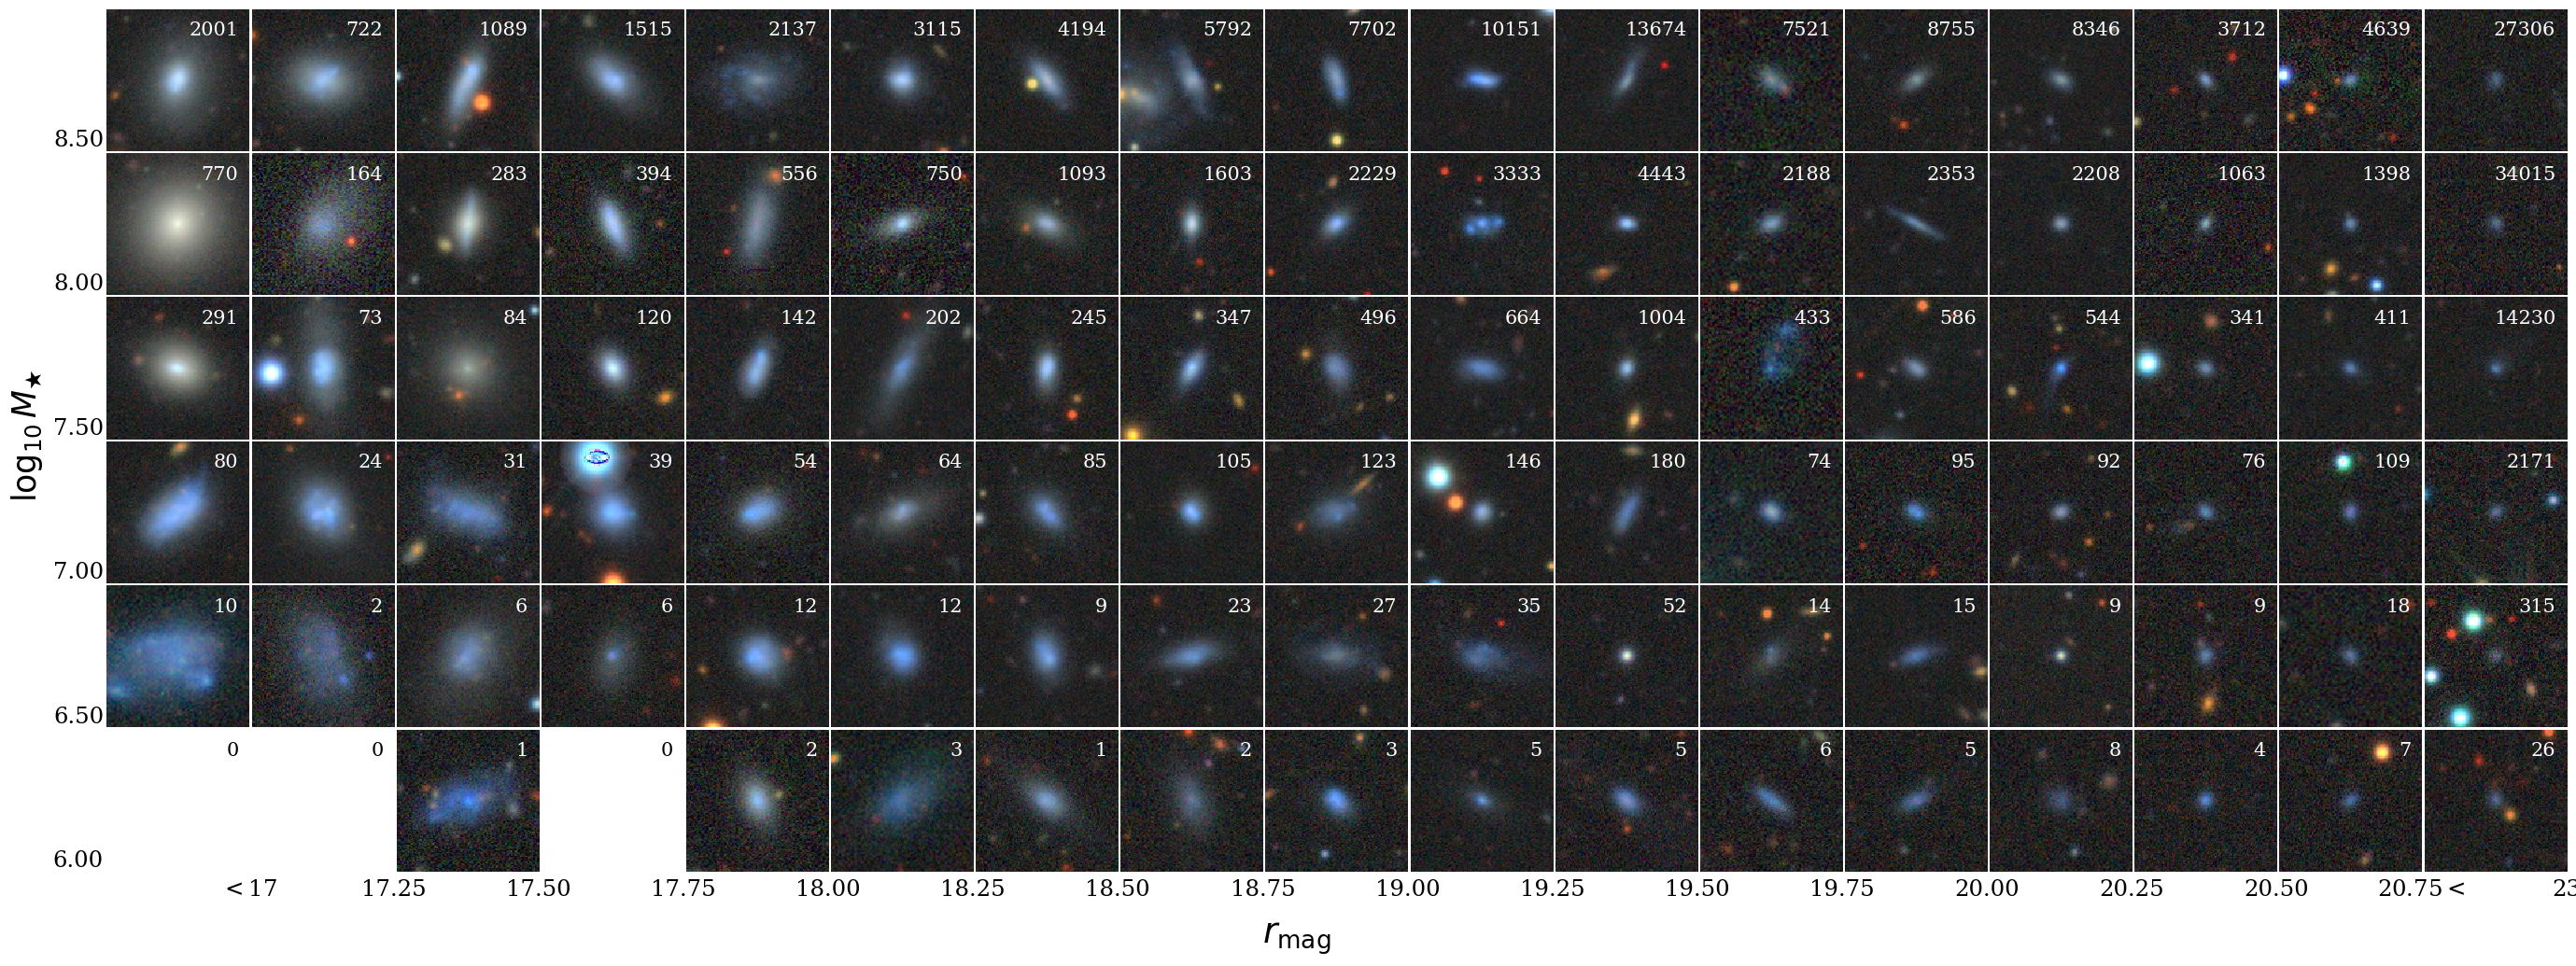

In [76]:

fig,ax = plot_tight_image_grid(images, counts, rmag_bins, logm_bins)

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/dwarf_imgs_grid.png",dpi=300)

plt.show()


In [6]:
from spectra_focus_plots import make_spectra_panel_sample

In [7]:

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False
# use a good colormap and don't interpolate the pixels
mpl.rc('image', cmap='viridis', interpolation='none', origin='lower')

eg_tgids =  [39627427021851828, 39627491345697115, 2705980336898048, 39627555304643301] #  [  39627322709513192, 39627345413284126, 2705974209019904, 39627357518039557 ]

        

In [19]:
tot_cat = Table.read("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/desi_y1_dwarf_combine_catalog.fits")


Total number of TGIDS = 4
INFO:spectra.py:453:read_spectra: iotime 0.024 sec to read spectra from:  coadd-main-bright-36627.fits at 2026-01-25T01:07:39.271287
INFO:coaddition.py:1024:coadd_cameras: coadding spectra across cameras took: 0.096 [sec]
INFO:spectra.py:453:read_spectra: iotime 0.038 sec to read spectra from:  coadd-main-bright-17477.fits at 2026-01-25T01:07:39.994661
INFO:coaddition.py:1024:coadd_cameras: coadding spectra across cameras took: 0.102 [sec]
INFO:spectra.py:453:read_spectra: iotime 0.053 sec to read spectra from:  coadd-main-dark-36717.fits at 2026-01-25T01:07:40.535077
INFO:coaddition.py:1024:coadd_cameras: coadding spectra across cameras took: 0.097 [sec]
INFO:spectra.py:453:read_spectra: iotime 0.024 sec to read spectra from:  coadd-main-dark-49050.fits at 2026-01-25T01:07:40.902026
INFO:coaddition.py:1024:coadd_cameras: coadding spectra across cameras took: 0.097 [sec]


/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/spectra_focus_plots.py:297: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  


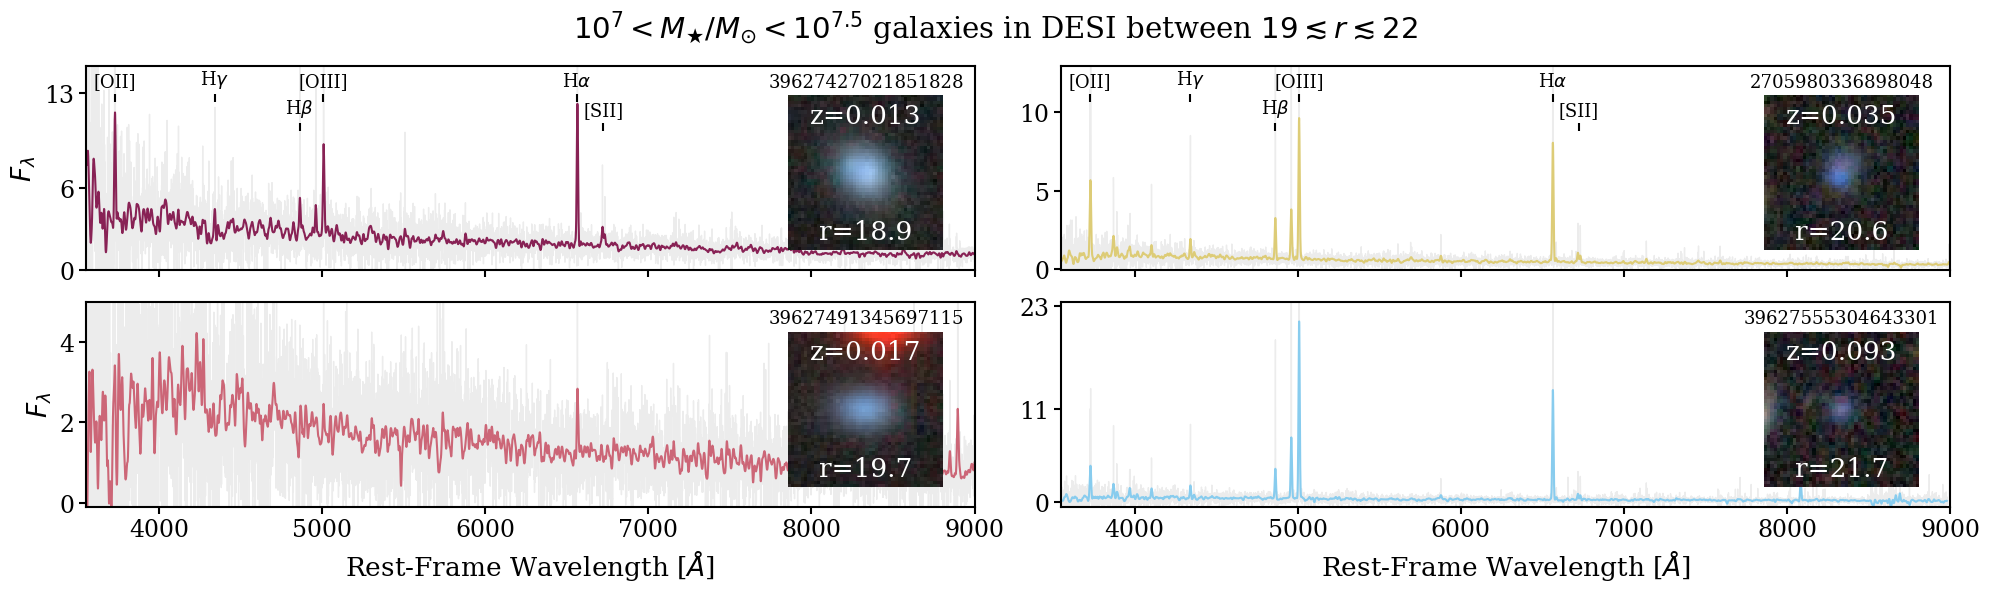

In [67]:

make_spectra_panel_sample(eg_tgids, "dwarf_egs", tot_cat, wave_min=3550, wave_max = 9000, lims =[ [0,15], [-0.1,5], [-0.1,13], [-0.5,23.5]  ] )
